In [12]:
import glob
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import random
from pathlib import Path
from tqdm import tqdm
from scipy.fft import fft
import scipy.stats as stats

In [13]:
def extract_surface_type_id(path):
    match = re.search(r'SurfaceTypeID_(\d+)', path)
    return int(match.group(1)) if match else None

data_dir = "../Datasets/Processed_Data/Labeled_Data_Without_GPS"
file_paths = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

files_df = pd.DataFrame({
    "full_path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
})

files_df["surface_id"] = files_df["full_path"].apply(extract_surface_type_id)
files_df["device"] = files_df["filename"].apply(lambda x: x.split('_')[3])

print(files_df["surface_id"].value_counts())

files_df.head(2)

surface_id
10    406
9     403
8      98
7      96
6      90
5      66
2      57
3      40
4      30
11     28
12     20
1      10
Name: count, dtype: int64


,full_path,filename,surface_id,device
0,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-02-15_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9,SamsungGalaxyJ7
1,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-09-02_SurfaceTypeID_9_SamsungGalaxyS7_exp...,9,SamsungGalaxyS7


In [14]:
first_file = files_df.iloc[0]['full_path']
df_first = pd.read_csv(first_file)
df_first.head(1)

,sensorName,valueX,valueY,valueZ,timestamp
0,Gyroscope,-0.001634,-0.007524,-0.000831,1.550261e+12


# Basic feature extraction

In [15]:

# Feature extraction code goes here (not shown in the provided snippets)

def zero_crossing_rate(signal):
    return ((signal[:-1] * signal[1:]) < 0).sum()

acc_result_list = []
gyro_result_list = []

WINDOW_SIZE = 512
STEP_SIZE = WINDOW_SIZE // 2

for idx, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    file_path = row['full_path']
    surface_id = row['surface_id']
    
    data_df = pd.read_csv(file_path)

    # Pad if data is shorter than one window
    if len(data_df) < WINDOW_SIZE:
        pad_size = WINDOW_SIZE - len(data_df)
        pad_df   = pd.concat([data_df] * (pad_size // len(data_df) + 1)).iloc[:pad_size]
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    # Pad last incomplete window with edge values
    remainder = len(data_df) % STEP_SIZE
    if remainder != 0:
        pad_size = WINDOW_SIZE - remainder
        pad_df   = data_df.iloc[-pad_size:].copy()
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)


    for start in range(0, len(data_df) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data_df[start:start + WINDOW_SIZE]

        svm = np.sqrt(window['valueX']**2 + window['valueY']**2 + window['valueZ']**2)

        fft_val_x = np.abs(np.fft.fft(window['valueX'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_y = np.abs(np.fft.fft(window['valueY'].to_numpy()))[:WINDOW_SIZE//2]
        fft_val_z = np.abs(np.fft.fft(window['valueZ'].to_numpy()))[:WINDOW_SIZE//2]

        features = {

            # Time domain features
            'mean_x': window['valueX'].mean(),
            'mean_y': window['valueY'].mean(),
            'mean_z': window['valueZ'].mean(),
            'std_x': window['valueX'].std(),
            'std_y': window['valueY'].std(),
            'std_z': window['valueZ'].std(),
            'var_x': window['valueX'].var(),
            'var_y': window['valueY'].var(),
            'var_z': window['valueZ'].var(),
            'sum_x': window['valueX'].sum(),
            'sum_y': window['valueY'].sum(),
            'sum_z': window['valueZ'].sum(),
            'max_x': window['valueX'].max(),
            'max_y': window['valueY'].max(),
            'max_z': window['valueZ'].max(),
            'min_x': window['valueX'].min(),
            'min_y': window['valueY'].min(),
            'min_z': window['valueZ'].min(),

            # Higher-order statistics
            'skew_x': stats.skew(window['valueX']),
            'kurt_x': stats.kurtosis(window['valueX']),
            'skew_y': stats.skew(window['valueY']),
            'kurt_y': stats.kurtosis(window['valueY']),
            'skew_z': stats.skew(window['valueZ']),
            'kurt_z': stats.kurtosis(window['valueZ']),

            # Zero Crossing Rate
            'zcr_x': zero_crossing_rate(window['valueX'].values),
            'zcr_y': zero_crossing_rate(window['valueY'].values),
            'zcr_z': zero_crossing_rate(window['valueZ'].values),

            # Single Vector Magnitude (SVM) features
            'svm_mean': svm.mean(),
            'svm_std':  svm.std(),
            'svm_max':  svm.max(),

            # Axis correlations
            'corr_xy': window['valueX'].corr(window['valueY']),
            'corr_xz': window['valueX'].corr(window['valueZ']),
            'corr_yz': window['valueY'].corr(window['valueZ']),

            # Frequency domain features
            'dominant_freq_x': np.argmax(fft_val_x),
            'spectral_energy_x': np.sum(fft_val_x**2),
            'spectral_entropy_x': -np.sum((fft_val_x/fft_val_x.sum()) * np.log(fft_val_x/fft_val_x.sum() + 1e-10)),
            
            'dominant_freq_y': np.argmax(fft_val_y),
            'spectral_energy_y': np.sum(fft_val_y**2),
            'spectral_entropy_y': -np.sum((fft_val_y/fft_val_y.sum()) * np.log(fft_val_y/fft_val_y.sum() + 1e-10)),
            
            'dominant_freq_z': np.argmax(fft_val_z),
            'spectral_energy_z': np.sum(fft_val_z**2),
            'spectral_entropy_z': -np.sum((fft_val_z/fft_val_z.sum()) * np.log(fft_val_z/fft_val_z.sum() + 1e-10)),
            
            'surface_id': surface_id,
        }

        if 'accelerometer' in file_path.lower():
            acc_result_list.append(features)
        elif 'gyroscope' in file_path.lower():
            gyro_result_list.append(features)

Processing files: 100%|██████████| 1344/1344 [00:48<00:00, 27.64it/s] 


In [16]:
# Create DataFrames from the extracted features
acc_df = pd.DataFrame(acc_result_list)
gyro_df = pd.DataFrame(gyro_result_list)

# Create output directory if it doesn't exist
output_dir = "../Datasets/ExtractedFeatures"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Save to CSV files
acc_df.to_csv(os.path.join(output_dir, "accelerometer_features.csv"), index=False)
gyro_df.to_csv(os.path.join(output_dir, "gyroscope_features.csv"), index=False)

print(f"Accelerometer features saved: {len(acc_df)} samples")
print(f"Gyroscope features saved: {len(gyro_df)} samples")

Accelerometer features saved: 15835 samples
Gyroscope features saved: 15686 samples


# TimesFM feature extraction

In [53]:
import pandas as pd
import numpy as np
import os
import glob
import re
from huggingface_hub import snapshot_download
from transformers import TimesFmModel, TimesFmConfig
import torch
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import Counter
from collections import defaultdict

/opt/miniconda3/envs/timesFM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

model_id = "google/timesfm-2.0-500m-pytorch"
model = TimesFmModel.from_pretrained(model_id)
model = model.to(device)
model.eval()

Using device: mps


Loading weights: 0it [00:00, ?it/s]
TimesFmModel LOAD REPORT from: google/timesfm-2.0-500m-pytorch
Key                                             | Status     | 
------------------------------------------------+------------+-
decoder.layers.{0...49}.input_layernorm.weight  | UNEXPECTED | 
decoder.layers.{0...49}.mlp.down_proj.weight    | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.o_proj.bias   | UNEXPECTED | 
decoder.layers.{0...49}.mlp.down_proj.bias      | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.o_proj.weight | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.v_proj.bias   | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.v_proj.weight | UNEXPECTED | 
decoder.layers.{0...49}.mlp.gate_proj.bias      | UNEXPECTED | 
decoder.layers.{0...49}.mlp.gate_proj.weight    | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.q_proj.bias   | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.q_proj.weight | UNEXPECTED | 
decoder.layers.{0...49}.self_attn.k_proj.bias   | UNEXPECTED | 
decod

TimesFmModel(
  (input_ff_layer): TimesFmResidualBlock(
    (input_layer): Linear(in_features=64, out_features=1280, bias=True)
    (activation): SiLU()
    (output_layer): Linear(in_features=1280, out_features=1280, bias=True)
    (residual_layer): Linear(in_features=64, out_features=1280, bias=True)
  )
  (freq_emb): Embedding(3, 1280)
  (layers): ModuleList(
    (0-49): 50 x TimesFmDecoderLayer(
      (self_attn): TimesFmAttention(
        (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (k_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (o_proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): TimesFmMLP(
        (gate_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (down_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (layer_norm): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
      )

In [55]:

WINDOW_SIZE = 1024
STEP_SIZE   = WINDOW_SIZE // 2

def pad_data(data_df):
    """Pad data if shorter than window size or has incomplete last window."""
    if len(data_df) < WINDOW_SIZE:
        pad_size = WINDOW_SIZE - len(data_df)
        pad_df   = pd.concat([data_df] * (pad_size // len(data_df) + 1)).iloc[:pad_size]
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    remainder = len(data_df) % STEP_SIZE
    if remainder != 0:
        pad_size = WINDOW_SIZE - remainder
        pad_df   = data_df.iloc[-pad_size:].copy()
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    return data_df


def extract_windows(data_df, sensor_name):
    """Extract sliding windows for a specific sensor."""
    sensor_df = data_df[data_df['sensorName'] == sensor_name][['valueX', 'valueY', 'valueZ']].reset_index(drop=True)
    sensor_df = pad_data(sensor_df)

    windows = []
    for start in range(0, len(sensor_df) - WINDOW_SIZE + 1, STEP_SIZE):
        window = sensor_df.iloc[start : start + WINDOW_SIZE].values 
        windows.append(window)

    return np.array(windows)  # (N, 1024, 3)


def extract_embeddings(model, windows, batch_size=32):
    """
    Extract embeddings from TimesFM model.
    windows: (N, 1024, 3) — N windows, each with X, Y, Z channels
    Returns: (N, 3, hidden_dim) — embedding per axis, then concatenated
    """
    all_embeddings = []

    for i in tqdm(range(0, len(windows), batch_size), desc="Extracting embeddings"):
        batch = windows[i : i + batch_size]  # (B, 1024, 3)

        # Process each axis separately (TimesFM is univariate)
        axis_embeddings = []
        for axis_idx in range(3):
            axis_data = batch[:, :, axis_idx]  # (B, 1024)

            batch_tensor = torch.tensor(axis_data, dtype=torch.float32).to(device)
            padding      = torch.zeros(batch_tensor.shape, dtype=torch.long).to(device)
            freq         = torch.zeros(batch_tensor.shape[0], dtype=torch.long).view(-1, 1).to(device)

            with torch.no_grad():
                outputs = model(
                    past_values=batch_tensor,
                    past_values_padding=padding,
                    freq=freq
                )

            # (B, patches, hidden_dim) -> mean pool -> (B, hidden_dim)
            pooled = torch.mean(outputs.last_hidden_state, dim=1)
            axis_embeddings.append(pooled.detach().cpu().numpy())

        # Concatenate X, Y, Z embeddings -> (B, hidden_dim * 3)
        combined = np.concatenate(axis_embeddings, axis=1)
        all_embeddings.append(combined)

    return np.vstack(all_embeddings)  # (N, hidden_dim * 3)


# ── Main loop ──────────────────────────────────────────────────────────────────

acc_embeddings_list  = []
gyro_embeddings_list = []

for idx, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    file_path  = row['full_path']
    surface_id = row['surface_id']
    device_id  = row['device']

    data_df = pd.read_csv(file_path)

    for sensor, result_list in [("Accelerometer", acc_embeddings_list),
                                 ("Gyroscope",     gyro_embeddings_list)]:

        if sensor not in data_df['sensorName'].values:
            continue

        windows    = extract_windows(data_df, sensor)        # (N, 1024, 3)
        embeddings = extract_embeddings(model, windows)      # (N, hidden_dim * 3)

        for emb in embeddings:
            result_list.append({
                'embedding':   emb,
                'surface_id':  surface_id,
                'device':      device_id,
                'file':        row['filenamex   ']
            })

acc_emb_df  = pd.DataFrame(acc_embeddings_list)
gyro_emb_df = pd.DataFrame(gyro_embeddings_list)

print(f"Acc  embeddings shape: {np.vstack(acc_emb_df['embedding'].values).shape}")
print(f"Gyro embeddings shape: {np.vstack(gyro_emb_df['embedding'].values).shape}")

Processing files: 100%|██████████| 485/485 [09:09<00:00,  1.13s/it]


Acc  embeddings shape: (2775, 3840)
Gyro embeddings shape: (2744, 3840)


In [56]:
acc_emb_df.head(2)

,embedding,surface_id,device,file
0,"[-1.840976, -0.83720374, -1.1644001, -0.616652...",9,SamsungGalaxyJ7,2019-02-05_SurfaceTypeID_9_SamsungGalaxyJ7_exp...
1,"[0.1526488, -6.376237, -1.131531, 0.09306398, ...",9,SamsungGalaxyJ7,2020-05-02_SurfaceTypeID_9_SamsungGalaxyJ7_exp...


In [57]:
# output_dir = "../Datasets/ExtractedEmbeddings"
# Path(output_dir).mkdir(parents=True, exist_ok=True) 

# acc_emb_df.to_csv(os.path.join(output_dir, "accelerometer_timesfm_embeddings.csv"), index=False)
# gyro_emb_df.to_csv(os.path.join(output_dir, "gyroscope_timesfm_embeddings.csv"), index=False)

In [63]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# Parse embeddings
X_embeddings = np.vstack(acc_emb_df['embedding'].values)
y_embeddings = (acc_emb_df['surface_id'] - 2).values

# Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_embeddings)

# KMeans — n_clusters matches number of surface types
n_clusters = len(np.unique(y_embeddings))

kmeans     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Evaluation
ari       = adjusted_rand_score(y_embeddings, cluster_labels)
nmi       = normalized_mutual_info_score(y_embeddings, cluster_labels)
silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Clusters found:       {n_clusters}")
print(f"Adjusted Rand Index:  {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"NMI Score:            {nmi:.4f}  (1.0 = perfect)")
print(f"Silhouette Score:     {silhouette:.4f}  (1.0 = perfect, <0 = bad)")





Clusters found:       9
Adjusted Rand Index:  0.0024  (1.0 = perfect, 0 = random)
NMI Score:            0.0114  (1.0 = perfect)
Silhouette Score:     0.0205  (1.0 = perfect, <0 = bad)


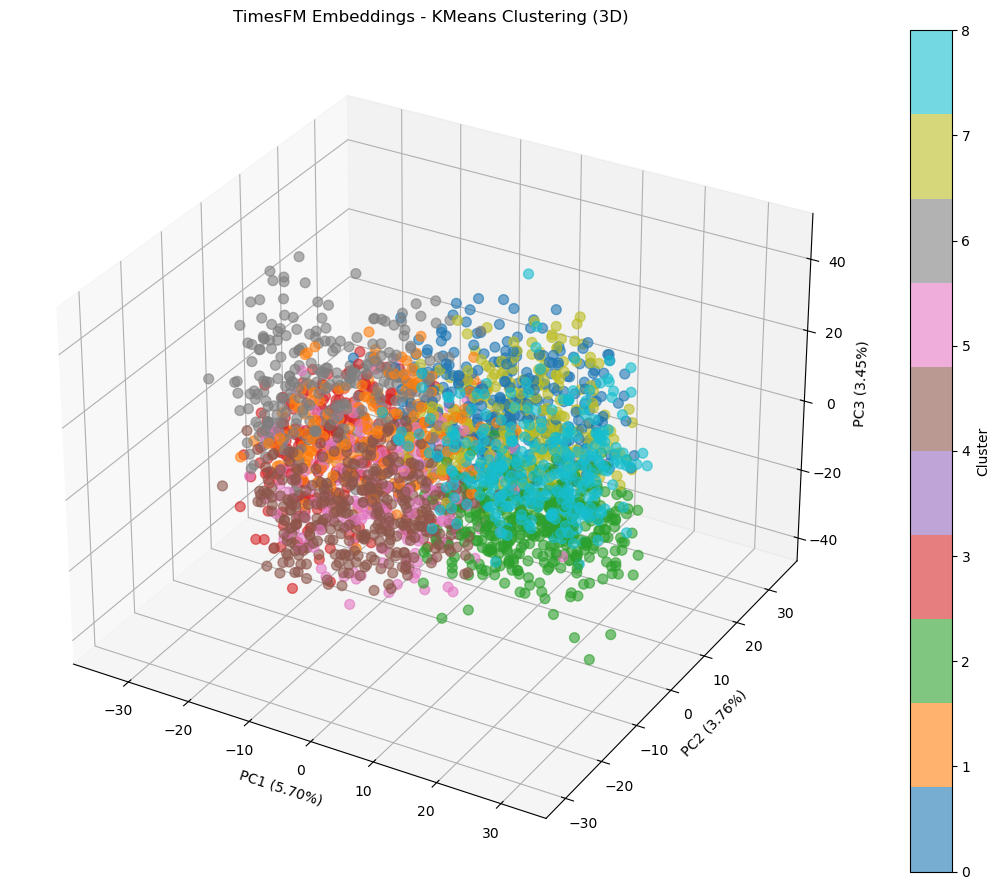

In [64]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce embeddings to 3D using PCA
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                     c=cluster_labels, cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax.set_title('TimesFM Embeddings - KMeans Clustering (3D)')
plt.tight_layout()
plt.show()

In [65]:
from collections import Counter

# Count samples per cluster
cluster_counts = Counter(cluster_labels)
print("Samples per cluster:")
for cluster_id in sorted(cluster_counts.keys()):
    print(f"  Cluster {cluster_id}: {cluster_counts[cluster_id]} samples")

# Map clusters to true surface classes
cluster_to_class = {}
for cluster_id in range(n_clusters):
    mask = cluster_labels == cluster_id
    true_classes = y_embeddings[mask]
    most_common_class = Counter(true_classes).most_common(1)[0][0]
    cluster_to_class[cluster_id] = most_common_class

print("\nCluster to Surface Class mapping:")
for cluster_id, surface_class in sorted(cluster_to_class.items()):
    print(f"  Cluster {cluster_id} -> Surface Class {surface_class + 2}")

Samples per cluster:
  Cluster 0: 333 samples
  Cluster 1: 248 samples
  Cluster 2: 422 samples
  Cluster 3: 265 samples
  Cluster 4: 382 samples
  Cluster 5: 237 samples
  Cluster 6: 263 samples
  Cluster 7: 302 samples
  Cluster 8: 323 samples

Cluster to Surface Class mapping:
  Cluster 0 -> Surface Class 8
  Cluster 1 -> Surface Class 6
  Cluster 2 -> Surface Class 8
  Cluster 3 -> Surface Class 8
  Cluster 4 -> Surface Class 7
  Cluster 5 -> Surface Class 8
  Cluster 6 -> Surface Class 6
  Cluster 7 -> Surface Class 7
  Cluster 8 -> Surface Class 6
